# Unrevised Instructions

1) Use glider datasets in this erddap https://gliders.ioos.us/erddap/

    Try to find other gliders that have similar Temperature and Salinity readings other places in the world. Graph the output using maps and matplotlib.

2) Using the above datasets, create a line graph output for the Temperature,
Salinity,  and sound speed (calculated/derived)  data over a time range at a
single depth (for a given point).

3) Using the above datasets, create a line graph for temperature, salinity,
and sound speed (calculated/derived) data for a single time over all depths
(for a given point).

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))


In [2]:
from erddapy import servers
glider_servers = next(server for label, server in servers.items() if "gliders" in server.url)
glider_servers

Server(description='NOAA IOOS NGDAC (National Glider Data Assembly Center)', url='https://gliders.ioos.us/erddap/')

In [3]:
from erddapy import servers
[{label: server.url} for label, server in servers.items()][:5]

[{'voto': 'https://erddap.observations.voiceoftheocean.org/erddap/'},
 {'slgo-ogsl': 'https://erddap.ogsl.ca/erddap/'},
 {'cswc': 'https://coastwatch.pfeg.noaa.gov/erddap/'},
 {'apdrc': 'https://apdrc.soest.hawaii.edu/erddap/'},
 {'ncei': 'https://www.ncei.noaa.gov/erddap/'}]

## Get Datasets for Each Grid

In [4]:
from concurrent.futures import ThreadPoolExecutor
from urllib.error import HTTPError
from erddap_client.erddap_wrapper import ErddapIngestor, GLIDER_URL


def fetch_grid_dataset(grid_bounds):
    min_lat, max_lat, min_lon, max_lon = grid_bounds
    grid_label = f"lat_{min_lat}_{max_lat}_lon_{min_lon}_{max_lon}"
    worker_ingestor = ErddapIngestor(GLIDER_URL)

    try:
        dataset_df = worker_ingestor.dataset_search(
            min_lat=min_lat,
            max_lat=max_lat,
            min_lon=min_lon,
            max_lon=max_lon,
        ).assign(grid_label=grid_label)
        return "dataset", grid_label, dataset_df
    except HTTPError:
        return "empty", grid_label, {
            "min_lat": min_lat,
            "max_lat": max_lat,
            "min_lon": min_lon,
            "max_lon": max_lon,
        }

grid_datasets = {}
no_dataset_grids = {}
grid_step_size = 10
grid_bounds_list = [
    (lat, lat + grid_step_size, lon, lon + grid_step_size)
    for lat in range(-60, 60, grid_step_size)
    for lon in range(-180, 180, grid_step_size)
]
max_workers = min(16, len(grid_bounds_list)) or 1

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    for status, grid_label, payload in executor.map(fetch_grid_dataset, grid_bounds_list):
        if status == "dataset":
            grid_datasets[grid_label] = payload
        else:
            no_dataset_grids[grid_label] = payload


In [5]:
import pandas as pd

glider_datasets = pd.concat(grid_datasets.values(), ignore_index=True).drop_duplicates()
glider_datasets.columns

Index(['griddap', 'Subset', 'tabledap', 'Make A Graph', 'wms', 'files',
       'Title', 'Summary', 'FGDC', 'ISO 19115', 'Info', 'Background Info',
       'RSS', 'Email', 'Institution', 'Dataset ID', 'grid_label'],
      dtype='str')

## Combine datasets with overlapping grid labels

In [6]:
def combine_grid_labels(labels):
    unique_labels = pd.Series(labels).dropna().drop_duplicates()
    return ", ".join(unique_labels)

metadata_columns = [column for column in glider_datasets.columns if column != "grid_label"] # type: ignore
glider_datasets = (
    glider_datasets.groupby("Dataset ID", as_index=False, sort=False)
    .agg({
        **{column: "first" for column in metadata_columns if column != "Dataset ID"},
        "grid_label": combine_grid_labels,
    })
)

glider_datasets = glider_datasets[['Dataset ID','Title','Summary','Institution','grid_label']]
glider_datasets.head()

,Dataset ID,Title,Summary,Institution,grid_label
0,ng616-20180701T0000,ng616-20180701T0000,"AOML's Physical Oceanography Division, the Car...","Integrated Ocean Observing System,Naval Oceano...",lat_10_20_lon_-70_-60
1,ng467-20180701T0000,ng467-20180701T0000,This collaborative project is focused on colle...,"Integrated Ocean Observing System,Naval Oceano...",lat_10_20_lon_-70_-60
2,ng291-20180701T0000,ng291-20180701T0000,This collaborative project is focused on colle...,"Integrated Ocean Observing System,Naval Oceano...",lat_10_20_lon_-70_-60
3,ng222-20200908T1821,ng222-20200908T1821,Deployment of a Littoral Battlespace Sensing (...,Naval Oceanographic Office,lat_10_20_lon_-70_-60
4,ng231-20190901T0000,ng231-20190901T0000,This Naval Oceanographic Office (NAVOCEANO) Li...,"Integrated Ocean Observing System,Naval Oceano...",lat_10_20_lon_-70_-60


## Get Metadata for each dataset

In [7]:
datasets_metadata_list = []

glider_ingestor = ErddapIngestor(GLIDER_URL)

for dataset_title in glider_datasets['Title']:  # type: ignore
    df_info = glider_ingestor.get_dataset_metadata(dataset_title)

    df_info['Title'] = dataset_title

    datasets_metadata_list.append(df_info)

datasets_metadata = pd.concat(datasets_metadata_list, ignore_index=True)
datasets_metadata[
    (datasets_metadata['Row Type'] == 'variable')
    & (
        (datasets_metadata['Variable Name'].str.contains('precise_lat'))
        | (datasets_metadata['Variable Name'].str.contains('precise_lon'))
        | (datasets_metadata['Variable Name'] == 'salinity')
        | (datasets_metadata['Variable Name'] == 'temperature')
    )
].head(8)

,Row Type,Variable Name,Attribute Name,Data Type,Value,Title
541,variable,precise_lat,NaN,double,NaN,ng616-20180701T0000
562,variable,precise_lon,NaN,double,NaN,ng616-20180701T0000
944,variable,salinity,NaN,float,NaN,ng616-20180701T0000
1099,variable,temperature,NaN,float,NaN,ng616-20180701T0000
1743,variable,precise_lat,NaN,double,NaN,ng467-20180701T0000
1764,variable,precise_lon,NaN,double,NaN,ng467-20180701T0000
2126,variable,salinity,NaN,float,NaN,ng467-20180701T0000
2281,variable,temperature,NaN,float,NaN,ng467-20180701T0000


In [8]:
datasets_metadata[
    (datasets_metadata['Row Type'] == 'variable')
    & (
        (datasets_metadata['Variable Name'].str.contains('precise_lat'))
        | (datasets_metadata['Variable Name'].str.contains('precise_lon'))
        | (datasets_metadata['Variable Name'] == 'salinity')
        | (datasets_metadata['Variable Name'] == 'temperature')
        | (datasets_metadata['Variable Name'].str.contains('time'))
        | (datasets_metadata['Variable Name'].str.contains('sound'))
        | (datasets_metadata['Variable Name'].str.contains('depth'))
    )
    & (datasets_metadata['Title'] == 'ng616-20180701T0000')
]

,Row Type,Variable Name,Attribute Name,Data Type,Value,Title
110,variable,time,NaN,double,NaN,ng616-20180701T0000
164,variable,depth,NaN,float,NaN,ng616-20180701T0000
295,variable,dtime,NaN,double,NaN,ng616-20180701T0000
511,variable,mdepth,NaN,float,NaN,ng616-20180701T0000
541,variable,precise_lat,NaN,double,NaN,ng616-20180701T0000
562,variable,precise_lon,NaN,double,NaN,ng616-20180701T0000
583,variable,precise_time,NaN,double,NaN,ng616-20180701T0000
944,variable,salinity,NaN,float,NaN,ng616-20180701T0000
1039,variable,sound_speed,NaN,float,NaN,ng616-20180701T0000
1099,variable,temperature,NaN,float,NaN,ng616-20180701T0000


## Test Whether all Datasets Have the Same Coordinate Vars

In [9]:
glider_dataset_count = len(datasets_metadata['Title'].unique())

variables = ["time","precise_lat","precise_lon","depth","salinity","temperature","sound_speed"]

row_count_for_dataset_vars = datasets_metadata[
    (datasets_metadata['Row Type'] == 'variable')
    & 
    (
        datasets_metadata['Variable Name'].isin(variables)
    ) 
].shape[0]

variable_count = len(variables)

assert glider_dataset_count, (row_count_for_dataset_vars / variable_count)

In [10]:
import numpy as np

np.arange(50)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

## Line Graphs (Temp, Salinity and Sound Speed)

Data over a time range at a single depth (for a given point).

In [11]:
ng616 = glider_ingestor.get_dataset('ng616-20180701T0000', variables)
ng616_units = ng616[:1]
ng616_data = ng616[1:]

In [33]:
ng616_data.shape
ng616_units

,time,precise_lat,precise_lon,depth,salinity,temperature,sound_speed
0,UTC,degree_north,degree_east,m,1.0,Celsius,m s-1


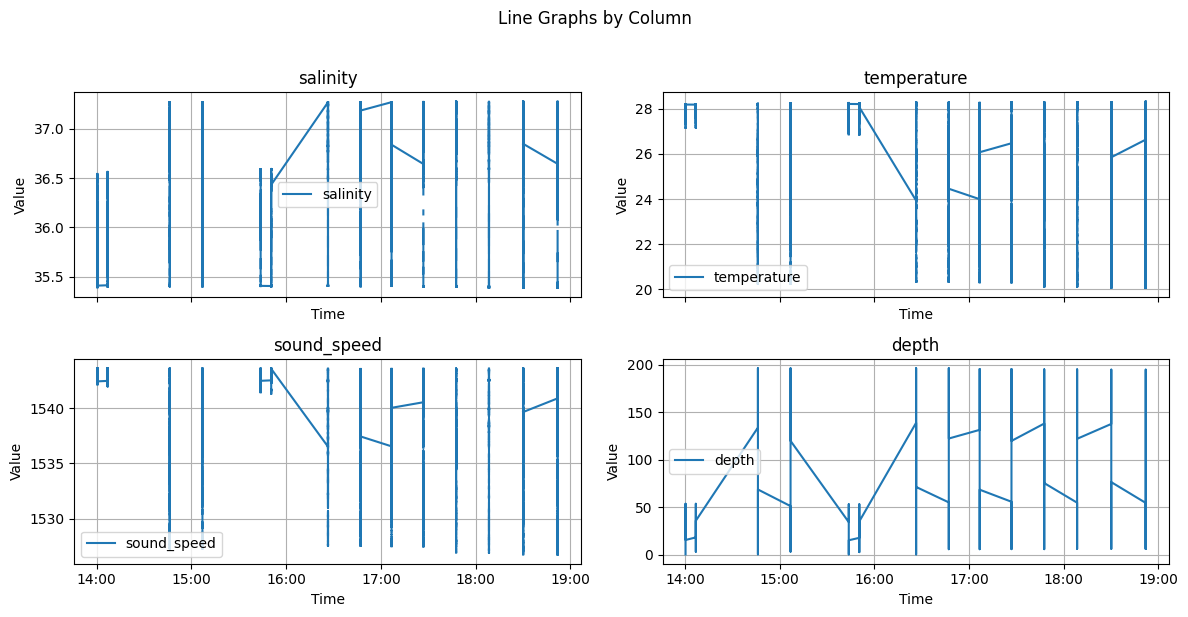

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plot_df = ng616_data.copy()
plot_df['time'] = pd.to_datetime(plot_df['time'],errors="coerce")
plot_df = plot_df[
    (plot_df["time"] < pd.Timestamp('2018-07-17 19:00:00+0000'))
    & (plot_df["time"] > pd.Timestamp('2018-07-17 14:00:00+0000'))

]
plot_df = plot_df.dropna(subset=['time']).sort_values(by="time",ascending=True)

y_cols = ["salinity","temperature","sound_speed","depth"]
for col in y_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

ncols = 2
nrows = int(np.ceil(len(y_cols) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(12,6),
    sharex=True
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, y_cols):
    ax.plot(plot_df["time"], plot_df[col], label=col)
    ax.set_title(col)
    ax.set_ylabel("Value")
    ax.grid(True)
    ax.legend()

for ax in axes[len(y_cols):]:
    ax.set_visible(False)

for ax in axes[:len(y_cols)]:
    ax.set_xlabel("Time")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.suptitle("Line Graphs by Column",y=1.02)
fig.tight_layout()
plt.show()

## Pull a datasets for a grid to test visualization

In [14]:
glider_datasets[glider_datasets['grid_label'] == 'lat_10_20_lon_-70_-60'][['Title','Institution']].head()

,Title,Institution
0,ng616-20180701T0000,"Integrated Ocean Observing System,Naval Oceano..."
1,ng467-20180701T0000,"Integrated Ocean Observing System,Naval Oceano..."
2,ng291-20180701T0000,"Integrated Ocean Observing System,Naval Oceano..."
3,ng222-20200908T1821,Naval Oceanographic Office
4,ng231-20190901T0000,"Integrated Ocean Observing System,Naval Oceano..."


In [15]:
grid_to_datasets = glider_datasets.groupby(by='grid_label').agg({
    "Dataset ID": lambda items: list(items) 
})
grid_to_datasets = grid_to_datasets.to_dict(orient="dict")['Dataset ID']

In [16]:
from concurrent.futures import ThreadPoolExecutor

def fetch_glider_rows(dataset_id):
    glider_data = glider_ingestor.get_dataset(dataset_id, variables)
    return glider_data.iloc[1:, :]

track_data_by_grid = {}

for grid, dataset_ids in grid_to_datasets.items():

    max_workers = min(8, len(dataset_ids)) or 1

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        grid_glider_data_list = list(executor.map(fetch_glider_rows, dataset_ids))

    glider_data_df = pd.concat(grid_glider_data_list, ignore_index=True)
    track_data_by_grid[grid] = glider_data_df

/home/wnkhan32/Repos/erddap_client/src/erddap_client/erddap_wrapper.py:75: DtypeWarning: Columns (0: precise_lat, 1: precise_lon, 2: depth, 3: temperature, 4: sound_speed) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(client.get_download_url(variables=variables))


KeyboardInterrupt: 

In [ ]:
grid_label = 'lat_10_20_lon_-70_-60'
glider_data_df = track_data_by_grid[grid_label]

In [ ]:
from erddap_client.mapping import make_map_axes
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig, ax, track = make_map_axes(glider_data_df, lon_pad=7, lat_pad=3)

ax.plot(track[lon_col], track[lat_col], color="tab:red", linewidth=2, transform=ccrs.PlateCarree())
ax.scatter(track[lon_col].iloc[0], track[lat_col].iloc[0], color="green", s=60, label="Start", transform=ccrs.PlateCarree())
ax.scatter(track[lon_col].iloc[-1], track[lat_col].iloc[-1], color="black", s=60, label="End", transform=ccrs.PlateCarree())

ax.set_title(f"Glider Track: {grid_label}")
ax.legend()
plt.show()

In [ ]:
salinity_col = 'salinity'

track_salinity = glider_data_df[[lon_col, lat_col, salinity_col]].copy()

for col in [lon_col, lat_col, salinity_col]:
    track_salinity[col] = pd.to_numeric(track_salinity[col], errors='coerce')

track_salinity = track_salinity.dropna()

fig, ax, _ = make_map_axes(track_salinity, lon_pad=7, lat_pad=3)

scatter = ax.scatter(
    track_salinity[lon_col],
    track_salinity[lat_col],
    c=track_salinity[salinity_col],
    cmap="viridis",
    s=18,
    transform=ccrs.PlateCarree(),
)
ax.plot(track_salinity[lon_col], track_salinity[lat_col], color="0.3", linewidth=0.8, alpha=0.5, transform=ccrs.PlateCarree())
ax.scatter(track_salinity[lon_col].iloc[0], track_salinity[lat_col].iloc[0], color="white", edgecolor="black", s=70, label="Start", transform=ccrs.PlateCarree())
ax.scatter(track_salinity[lon_col].iloc[-1], track_salinity[lat_col].iloc[-1], color="black", s=70, label="End", transform=ccrs.PlateCarree())

colorbar = plt.colorbar(scatter, ax=ax, pad=0.02, shrink=0.75)
colorbar.set_label(salinity_col)
ax.set_title(f"Glider Track Colored by Salinity: {grid_label}")
ax.legend()
plt.show()